# Obs: falta fazer limpeza nos dados, mas o codigo está rodando.

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("../data/train.csv")
teste = pd.read_csv("../data/test.csv")
df.duplicated().sum()

0

In [23]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,76518.0,38258.500000,22088.988286,0.00,19129.250000,38258.500000,57387.750000,76517.000
Marital status,76518.0,1.111934,0.441669,1.00,1.000000,1.000000,1.000000,6.000
Application mode,76518.0,16.054419,16.682337,1.00,1.000000,17.000000,39.000000,53.000
Application order,76518.0,1.644410,1.229645,0.00,1.000000,1.000000,2.000000,9.000
Course,76518.0,9001.286377,1803.438531,33.00,9119.000000,9254.000000,9670.000000,9991.000
Daytime/evening attendance,76518.0,0.915314,0.278416,0.00,1.000000,1.000000,1.000000,1.000
Previous qualification,76518.0,3.658760,8.623774,1.00,1.000000,1.000000,1.000000,43.000
Previous qualification (grade),76518.0,132.378766,10.995328,95.00,125.000000,133.100000,140.000000,190.000
Nacionality,76518.0,1.226600,3.392183,1.00,1.000000,1.000000,1.000000,109.000
Mother's qualification,76518.0,19.837633,15.399456,1.00,1.000000,19.000000,37.000000,44.000


In [24]:
carac_inicial = list(teste.columns)
carac_inicial

['id',
 'Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflat

In [25]:
for coluna in df.columns:
    print(f"{coluna} tem {df[coluna].nunique()} valores unicos")

id tem 76518 valores unicos
Marital status tem 6 valores unicos
Application mode tem 22 valores unicos
Application order tem 8 valores unicos
Course tem 19 valores unicos
Daytime/evening attendance tem 2 valores unicos
Previous qualification tem 21 valores unicos
Previous qualification (grade) tem 110 valores unicos
Nacionality tem 18 valores unicos
Mother's qualification tem 35 valores unicos
Father's qualification tem 39 valores unicos
Mother's occupation tem 40 valores unicos
Father's occupation tem 56 valores unicos
Admission grade tem 668 valores unicos
Displaced tem 2 valores unicos
Educational special needs tem 2 valores unicos
Debtor tem 2 valores unicos
Tuition fees up to date tem 2 valores unicos
Gender tem 2 valores unicos
Scholarship holder tem 2 valores unicos
Age at enrollment tem 46 valores unicos
International tem 2 valores unicos
Curricular units 1st sem (credited) tem 21 valores unicos
Curricular units 1st sem (enrolled) tem 24 valores unicos
Curricular units 1st sem 

In [26]:
poucos_valores = [coluna for coluna in df.columns if df[coluna].nunique() <= 8]

muitos_valores = [coluna for coluna in df.columns if df[coluna].nunique() >= 9]
len(muitos_valores)

27

C:\Users\Maycom\AppData\Local\Temp\ipykernel_20076\3213426669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[coluna], data=df, palette='pastel')
C:\Users\Maycom\AppData\Local\Temp\ipykernel_20076\3213426669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[coluna], data=df, palette='pastel')
C:\Users\Maycom\AppData\Local\Temp\ipykernel_20076\3213426669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[coluna], data=df, palette='pastel')
C:\Users\Maycom\AppData\Local\Temp\ipykernel_20076\3213426669.py:7: FutureWa

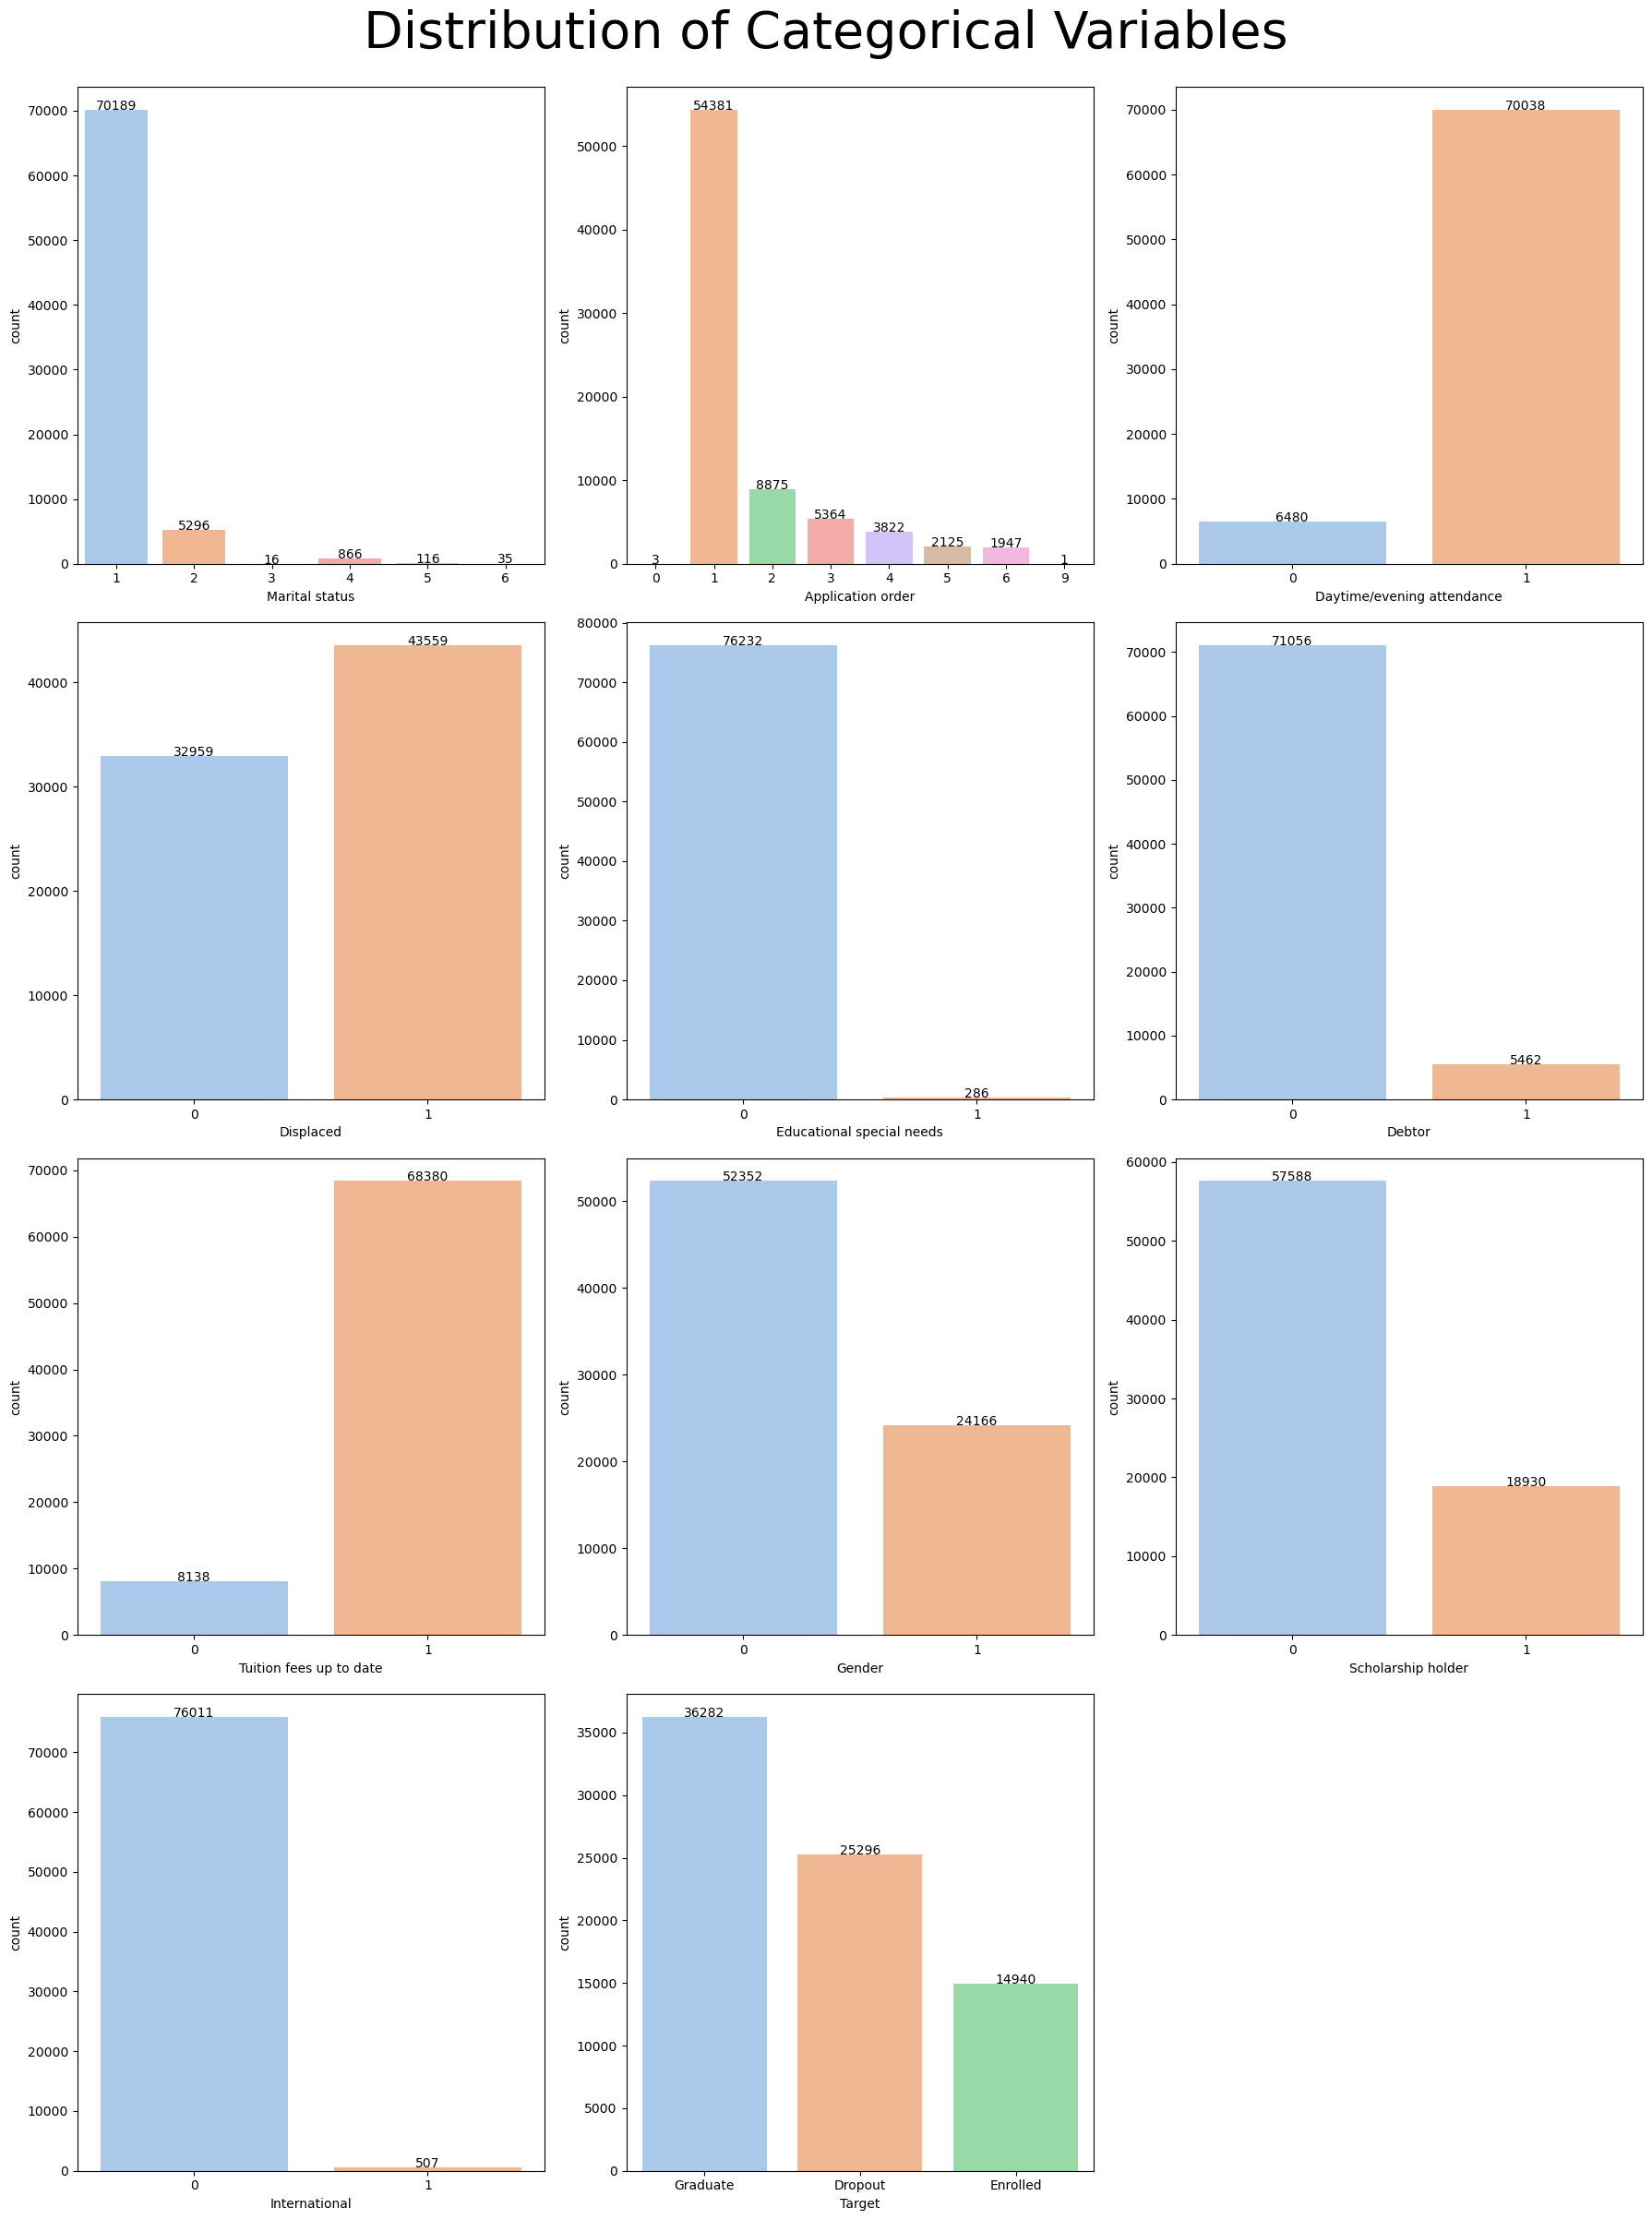

In [27]:
plt.figure(figsize=(18, 24))
plotnumber = 1

for coluna in poucos_valores:
    if plotnumber <= len(poucos_valores):
        ax = plt.subplot(4, 3, plotnumber)
        sns.countplot(x=df[coluna], data=df, palette='pastel')
        
        # Add labels to each bar in the plot
        for p in ax.patches:
            ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 3, f'{int(p.get_height())}', ha="center")
        
        plt.xlabel(coluna)
        # plt.xticks(rotation=45)
        plt.xlabel(coluna)
        
    plotnumber += 1

plt.suptitle('Distribution of Categorical Variables', fontsize=40, y=1)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

categorias = ['dropout', 'enrolled', 'graduate']
encoder = LabelEncoder()

# converter o target para valores numericos
df['Target'] = encoder.fit_transform(df['Target'])

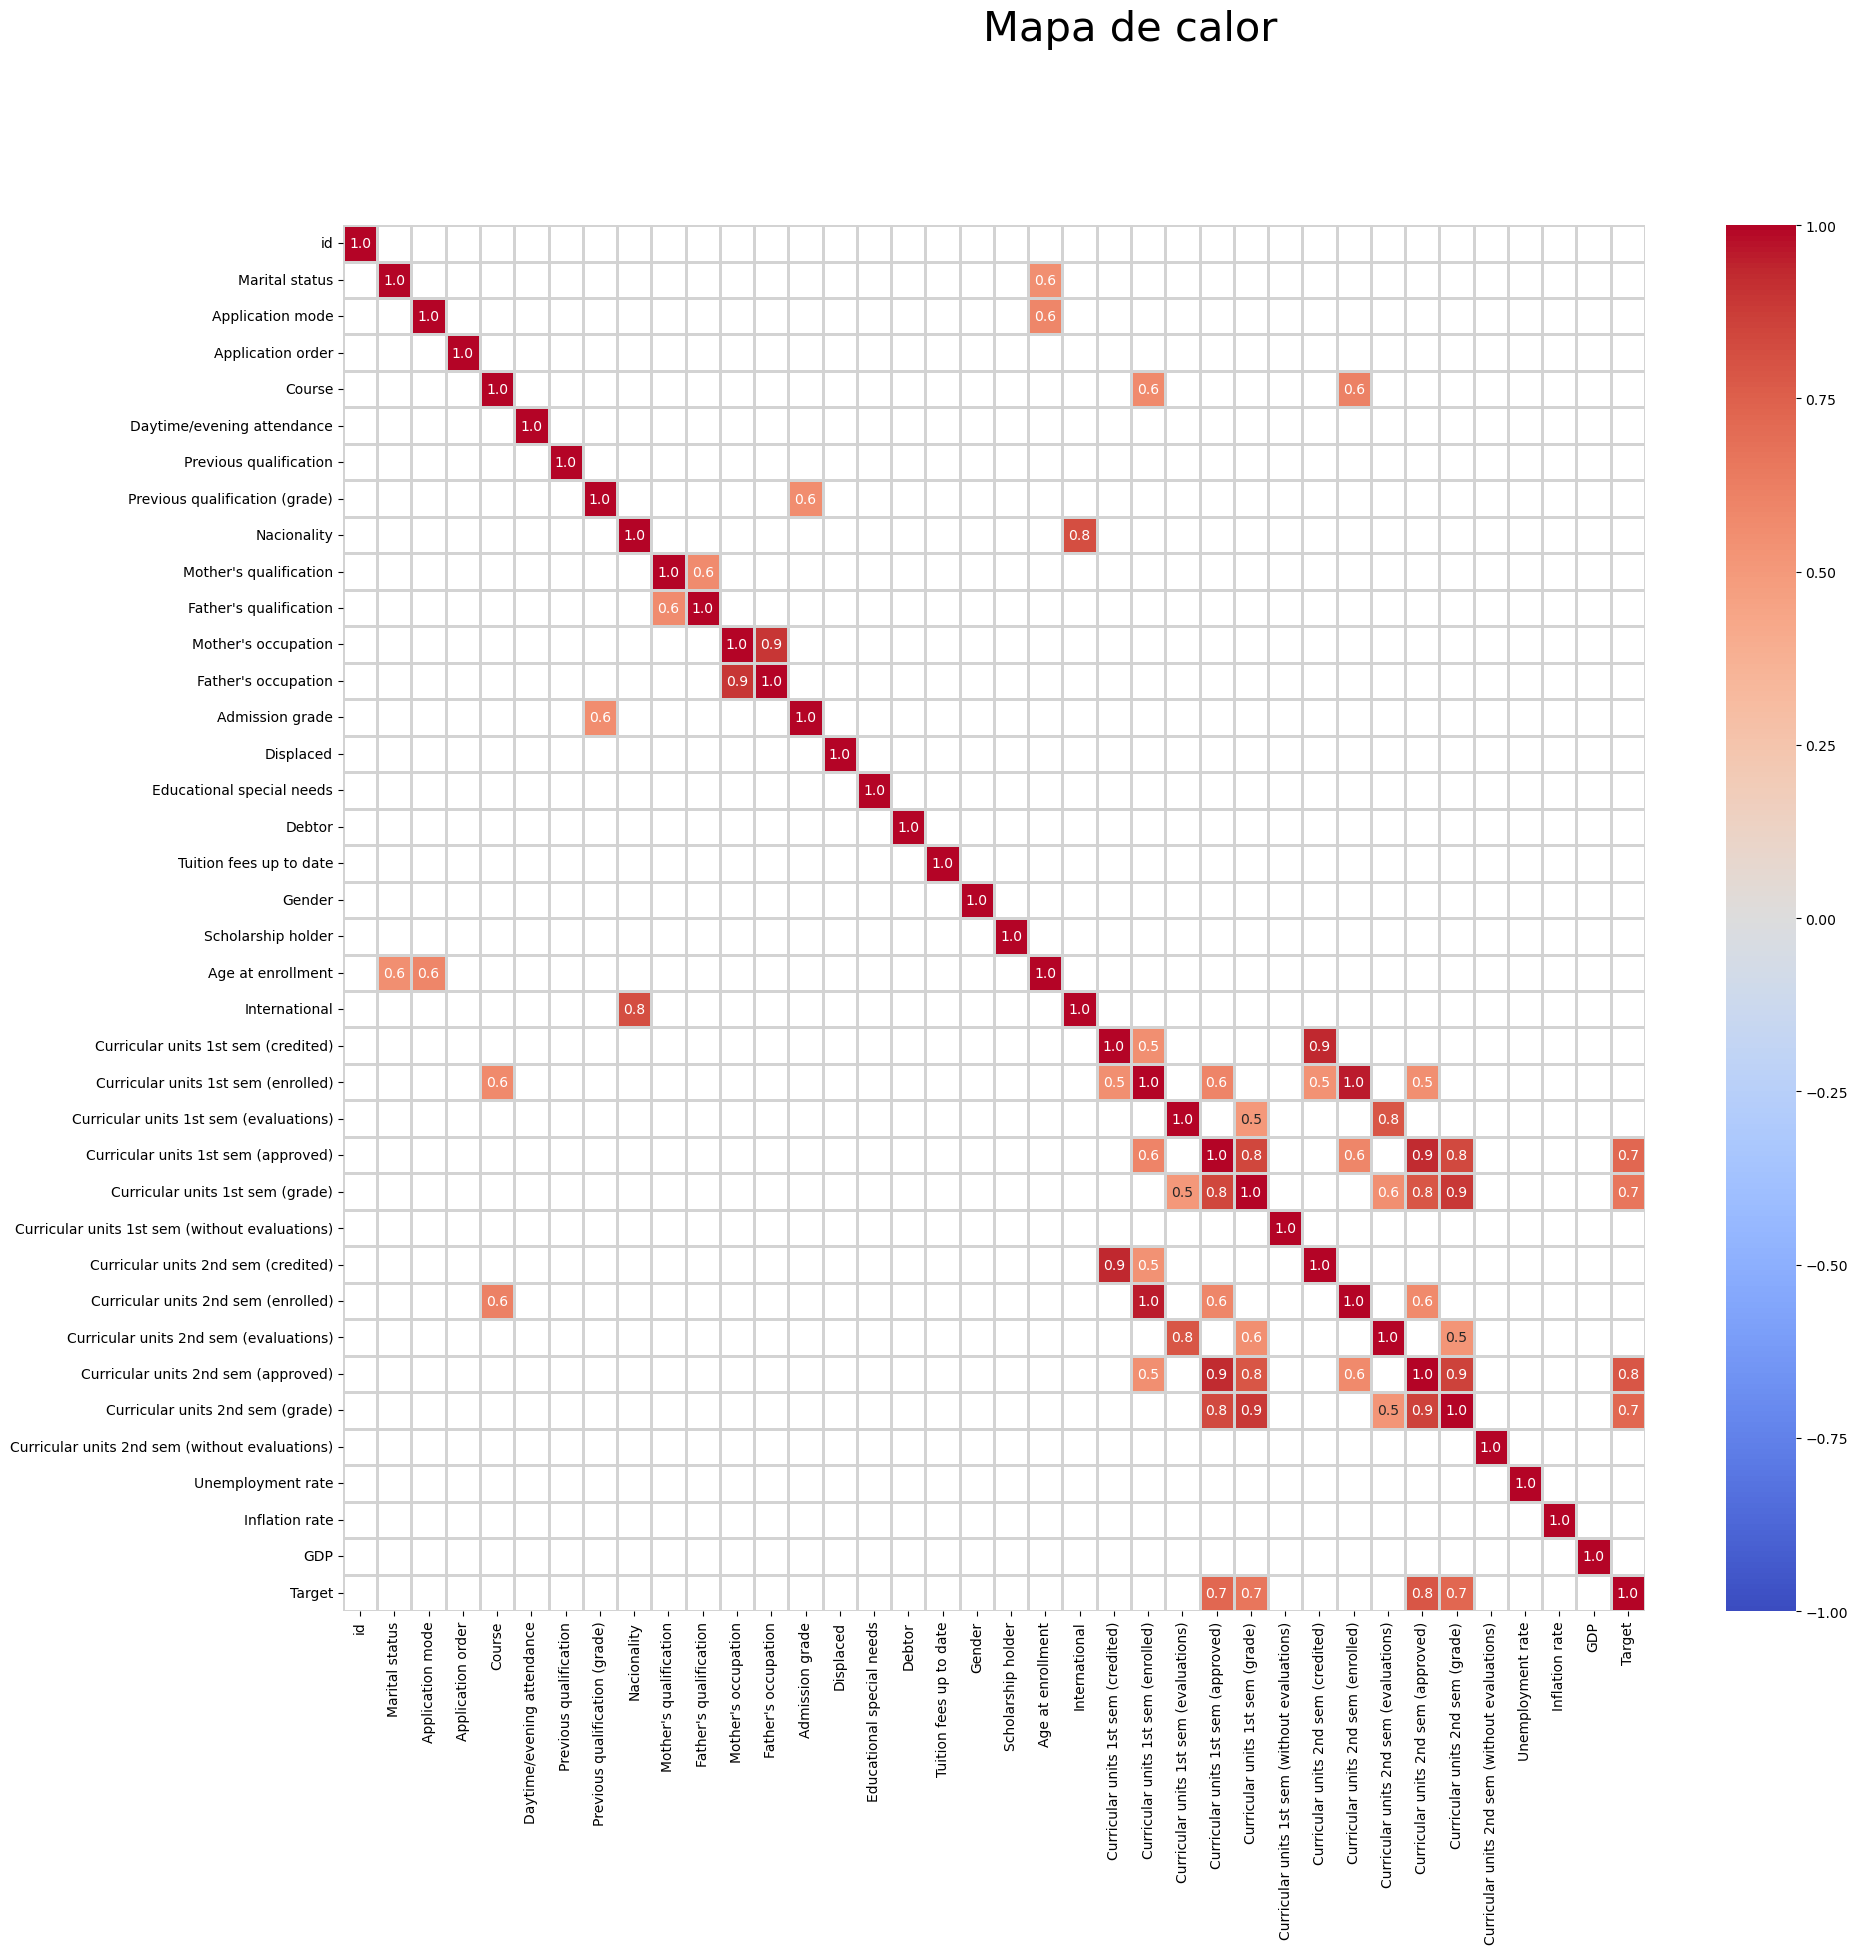

In [29]:
matriz_correlação = df.corr()

# Aplica o filtro para manter apenas as correlações > 0.5 ou < -0.5
filtro_correlação = matriz_correlação[(matriz_correlação > 0.5) | (matriz_correlação < -0.5)]

# Cria o mapa de calor com as correlações filtradas
plt.figure(figsize=(21, 18))
sns.heatmap(filtro_correlação, annot=True, cmap='coolwarm', fmt='.1f', linewidths=2, linecolor='lightgrey', vmin=-1, vmax=1)
plt.suptitle('Mapa de calor', fontsize=30, y=1)
plt.show()

In [30]:
matriz_correlação

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
id,1.000000,0.009796,-0.003956,-0.007129,0.002111,0.002192,-0.005403,-0.003635,0.002437,0.001159,...,-0.007880,-0.001978,-0.004794,-0.001264,0.000206,-0.003217,-0.001539,0.000648,0.002916,0.001411
Marital status,0.009796,1.000000,0.307324,-0.113951,0.023141,-0.323587,0.084064,-0.037717,0.004660,0.198373,...,0.037268,-0.005177,-0.021254,-0.111369,-0.111216,0.025689,-0.034481,0.019523,-0.046165,-0.123093
Application mode,-0.003956,0.307324,1.000000,-0.238497,0.040452,-0.354834,0.451252,-0.060636,0.005937,0.163590,...,0.159977,0.013383,0.047992,-0.274728,-0.271664,0.043298,0.098439,0.005130,-0.065964,-0.324830
Application order,-0.007129,-0.113951,-0.238497,1.000000,0.054168,0.147153,-0.155281,-0.013956,-0.016601,-0.062138,...,-0.066853,0.150224,-0.005080,0.166433,0.106326,-0.019871,-0.066022,-0.004206,0.031860,0.128394
Course,0.002111,0.023141,0.040452,0.054168,1.000000,-0.041557,-0.011349,-0.069488,-0.018786,0.018063,...,-0.066453,0.613658,0.328303,0.249484,0.316896,0.018007,-0.001982,0.007152,0.024719,0.154208
Daytime/evening attendance,0.002192,-0.323587,-0.354834,0.147153,-0.041557,1.000000,-0.057775,0.067332,0.006357,-0.199593,...,-0.071575,0.059326,0.023615,0.120979,0.110837,-0.014665,0.063861,-0.045270,0.037908,0.124484
Previous qualification,-0.005403,0.084064,0.451252,-0.155281,-0.011349,-0.057775,1.000000,0.105284,-0.010346,0.001252,...,0.128899,0.027733,0.080597,-0.069113,-0.059210,0.001979,0.130838,-0.046189,0.013527,-0.092319
Previous qualification (grade),-0.003635,-0.037717,-0.060636,-0.013956,-0.069488,0.067332,0.105284,1.000000,0.007707,-0.034497,...,-0.000320,0.030076,-0.048591,0.121827,0.089353,-0.011397,0.052112,0.028678,-0.053731,0.138119
Nacionality,0.002437,0.004660,0.005937,-0.016601,-0.018786,0.006357,-0.010346,0.007707,1.000000,-0.024836,...,0.006125,-0.012356,-0.000051,-0.008279,-0.005232,0.002579,0.001823,0.001536,0.020058,-0.004722
Mother's qualification,0.001159,0.198373,0.163590,-0.062138,0.018063,-0.199593,0.001252,-0.034497,-0.024836,1.000000,...,0.017870,-0.008667,0.002528,-0.083516,-0.082805,0.017145,-0.126686,0.068696,-0.099992,-0.085056


In [31]:
X_train = df[carac_inicial]
Y_train = df["Target"]
X_test = teste[carac_inicial]

# Criar uma função para fazer as validações cruzadas


In [32]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# criar uma função para

def validação_cruzada(modelo, X_train, Y_train, parametros, n_splits=10): 

        cv = KFold( n_splits=n_splits, shuffle=True, random_state=0)
        score_validação = []

        for fold, (treinamento, validação) in enumerate(cv.split(X_train)):
                
                X_fold_train = X_train.iloc[treinamento]
                Y_fold_train = Y_train.iloc[treinamento]
                X_val = X_train.iloc[validação]
                y_val = Y_train.iloc[validação]

                classificador = modelo(**parametros)
                classificador.fit(X_fold_train, Y_fold_train)

                y_previ_treino = classificador.predict(X_fold_train)
                y_previ_teste = classificador.predict(X_val)
                Acura_score = accuracy_score(Y_fold_train, y_previ_treino)
                Acura_validação = accuracy_score(y_val, y_previ_teste)

                print(f"Fold: {fold}, Train Accuracy: {Acura_score:.5f}, Val Accuracy: {Acura_validação:.5f}")
                print("-" * 50)

                score_validação.append(Acura_validação)

        Media_acuracia_validation = np.mean(score_validação)
        print("Media da acuraica da validação:", Media_acuracia_validation)
        return classificador,Media_acuracia_validation


In [33]:
from sklearn.ensemble import RandomForestClassifier

print('Random Forest Cross-Validation Results:\n')
rf_model, rf_mean_accuracy = validação_cruzada(RandomForestClassifier, X_train, Y_train, parametros={})
print(f"\nFinal Mean Validation Accuracy: {rf_mean_accuracy:.5f}")

Random Forest Cross-Validation Results:

Fold: 0, Train Accuracy: 0.99999, Val Accuracy: 0.82305
--------------------------------------------------
Fold: 1, Train Accuracy: 0.99996, Val Accuracy: 0.82005
--------------------------------------------------
Fold: 2, Train Accuracy: 0.99999, Val Accuracy: 0.82527
--------------------------------------------------
Fold: 3, Train Accuracy: 0.99999, Val Accuracy: 0.82031
--------------------------------------------------
Fold: 4, Train Accuracy: 1.00000, Val Accuracy: 0.82135
--------------------------------------------------
Fold: 5, Train Accuracy: 1.00000, Val Accuracy: 0.83560
--------------------------------------------------
Fold: 6, Train Accuracy: 0.99996, Val Accuracy: 0.82776
--------------------------------------------------
Fold: 7, Train Accuracy: 0.99999, Val Accuracy: 0.83573
--------------------------------------------------
Fold: 8, Train Accuracy: 0.99997, Val Accuracy: 0.82486
-----------------------------------------------